In [2]:
from google.colab import drive
drive.mount("/content/drive")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

drive_dir=Path("/content/drive/MyDrive/STQD6324_Labour_Shock")
out_dir=drive_dir/"outputs"
fig_dir=drive_dir/"figures"
fig_dir.mkdir(exist_ok=True)

print("ready")

Mounted at /content/drive
ready


In [3]:
#1.load data
index_df=pd.read_csv(out_dir/"country_year_evi_dri_index_2015_2024.csv")
matrix_df=pd.read_csv(out_dir/"readiness_matrix_2024.csv")
avg_df=pd.read_csv(out_dir/"country_average_index_2019_2024.csv")
km_df=pd.read_csv(out_dir/"sea_kmeans_cluster_2019_2024.csv")
compare_df=pd.read_csv(out_dir/"quadrant_cluster_agreement_2019_2024.csv")
quad_rule_df=pd.read_csv(out_dir/"quadrant_threshold_metadata_2024.csv")
print("index data:",index_df.shape)
print("matrix data:",matrix_df.shape)
print("average data:",avg_df.shape)
print("kmeans data:",km_df.shape)
print("comparison data:",compare_df.shape)

display(matrix_df)
display(compare_df)

index data: (90, 27)
matrix data: (9, 11)
average data: (9, 10)
kmeans data: (8, 7)
comparison data: (8, 10)


,country_code,country_name,is_benchmark,sample_role,year,evi_main,dri,risk_gap,evi_level,dri_level,readiness_quadrant
0,MYS,Malaysia,False,SEA sample,2024,0.603779,0.654579,-0.050799,High EVI,High DRI,High vulnerability + High readiness
1,VNM,Vietnam,False,SEA sample,2024,0.535187,0.645263,-0.110076,High EVI,High DRI,High vulnerability + High readiness
2,IDN,Indonesia,False,SEA sample,2024,0.599184,0.457498,0.141686,High EVI,Low DRI,High vulnerability + Low readiness
3,PHL,Philippines,False,SEA sample,2024,0.403789,0.434621,-0.030832,High EVI,Low DRI,High vulnerability + Low readiness
4,THA,Thailand,False,SEA sample,2024,0.347706,0.691902,-0.344196,Low EVI,High DRI,Low vulnerability + High readiness
5,SGP,Singapore,False,SEA sample,2024,0.306826,0.822436,-0.515611,Low EVI,High DRI,Low vulnerability + High readiness
6,LAO,Laos,False,SEA sample,2024,0.281652,0.267443,0.014209,Low EVI,Low DRI,Low vulnerability + Low readiness
7,KHM,Cambodia,False,SEA sample,2024,0.342318,0.419831,-0.077513,Low EVI,Low DRI,Low vulnerability + Low readiness
8,CHN,China,True,China benchmark,2024,0.778648,0.851093,-0.072446,High EVI,High DRI,High vulnerability + High readiness


,country_code,country_name,evi_main_avg,dri_avg,risk_gap_avg,avg_readiness_quadrant,quadrant_2024,cluster,cluster_label,method_agreement
0,IDN,Indonesia,0.624289,0.424548,0.199741,High vulnerability + Low readiness,High vulnerability + Low readiness,2,High vulnerability - High readiness,Different
1,LAO,Laos,0.323994,0.239553,0.084441,Low vulnerability + Low readiness,Low vulnerability + Low readiness,1,Low vulnerability - Low readiness,Same
2,MYS,Malaysia,0.613802,0.617094,-0.003292,High vulnerability + High readiness,High vulnerability + High readiness,2,High vulnerability - High readiness,Same
3,PHL,Philippines,0.422342,0.472602,-0.050259,High vulnerability + Low readiness,High vulnerability + Low readiness,1,Low vulnerability - Low readiness,Different
4,KHM,Cambodia,0.326620,0.396642,-0.070022,Low vulnerability + Low readiness,Low vulnerability + Low readiness,1,Low vulnerability - Low readiness,Same
5,VNM,Vietnam,0.534807,0.608690,-0.073882,High vulnerability + High readiness,High vulnerability + High readiness,2,High vulnerability - High readiness,Same
6,THA,Thailand,0.364550,0.692318,-0.327768,Low vulnerability + High readiness,Low vulnerability + High readiness,0,Low vulnerability - High readiness,Same
7,SGP,Singapore,0.385274,0.799231,-0.413956,Low vulnerability + High readiness,Low vulnerability + High readiness,0,Low vulnerability - High readiness,Same


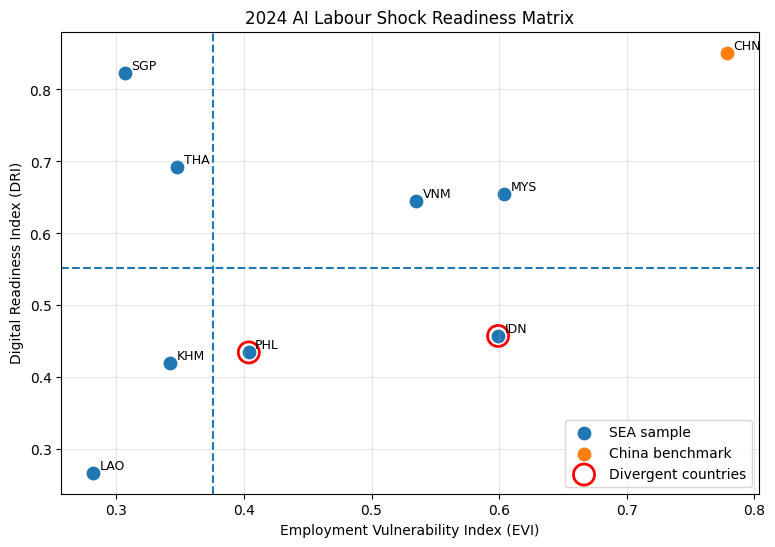

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_readiness_matrix.png


In [4]:
#2.2024 EVI-DRI quadrant scatter
evi_cut=quad_rule_df.loc[quad_rule_df["threshold_name"]=="evi_cut","value"].iloc[0]
dri_cut=quad_rule_df.loc[quad_rule_df["threshold_name"]=="dri_cut","value"].iloc[0]
plt.figure(figsize=(9,6))

for role in matrix_df["sample_role"].unique():
    temp=matrix_df[matrix_df["sample_role"]==role]
    plt.scatter(temp["evi_main"],temp["dri"],label=role,s=80)
highlight=matrix_df[matrix_df["country_code"].isin(["IDN","PHL"])]
plt.scatter(highlight["evi_main"],highlight["dri"],s=230,facecolors="none",
    edgecolors="red",linewidths=2,label="Divergent countries")

for i,r in matrix_df.iterrows():
    plt.text(r["evi_main"]+0.005,r["dri"]+0.005,r["country_code"],fontsize=9)

plt.axvline(evi_cut,linestyle="--")
plt.axhline(dri_cut,linestyle="--")
plt.xlabel("Employment Vulnerability Index (EVI)")
plt.ylabel("Digital Readiness Index (DRI)")
plt.title("2024 AI Labour Shock Readiness Matrix")
plt.legend()
plt.grid(True,alpha=0.3)
fig_path=fig_dir/"fig_2024_readiness_matrix.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()

print("figure saved:",fig_path)

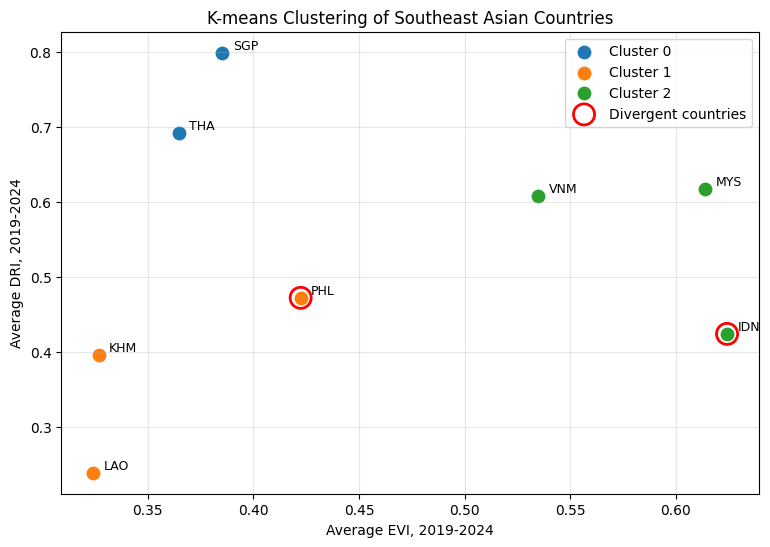

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_kmeans_scatter_2019_2024.png


In [5]:
#3.2019-2024 k-means scatter
plt.figure(figsize=(9,6))
for c in sorted(km_df["cluster"].unique()):
    temp=km_df[km_df["cluster"]==c]
    plt.scatter(temp["evi_main_avg"],temp["dri_avg"],label="Cluster "+str(c),s=80)
highlight=km_df[km_df["country_code"].isin(["IDN","PHL"])]
plt.scatter(highlight["evi_main_avg"],highlight["dri_avg"],s=230,facecolors="none",
    edgecolors="red",linewidths=2,label="Divergent countries")
for i,r in km_df.iterrows():
    plt.text(r["evi_main_avg"]+0.005,r["dri_avg"]+0.005,r["country_code"],fontsize=9)

plt.xlabel("Average EVI, 2019-2024")
plt.ylabel("Average DRI, 2019-2024")
plt.title("K-means Clustering of Southeast Asian Countries")
plt.legend()
plt.grid(True,alpha=0.3)
fig_path=fig_dir/"fig_kmeans_scatter_2019_2024.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()

print("figure saved:",fig_path)

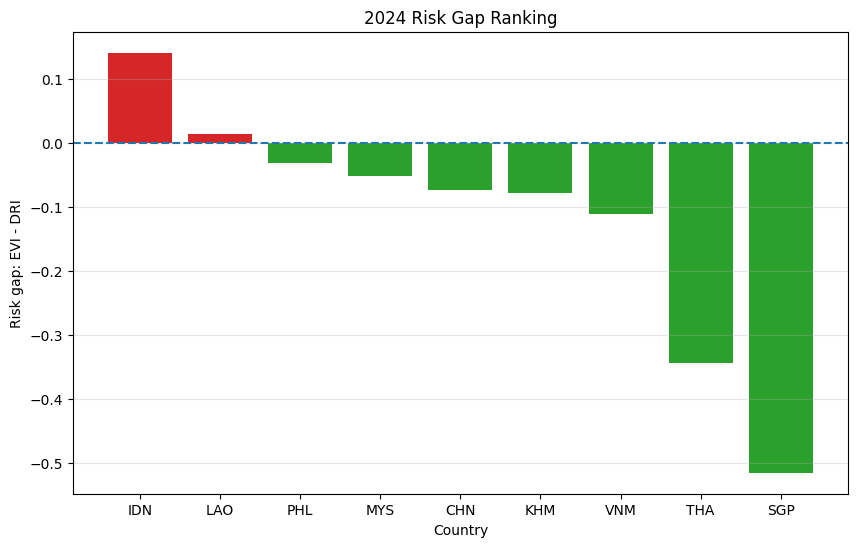

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_risk_gap_bar.png


In [6]:
#4.2024 risk gap bar chart
risk_2024=matrix_df.sort_values("risk_gap",ascending=False).copy()
colors=["#d62728" if v>0 else "#2ca02c" for v in risk_2024["risk_gap"]]

plt.figure(figsize=(10,6))
plt.bar(risk_2024["country_code"],risk_2024["risk_gap"],color=colors)
plt.axhline(0,linestyle="--")
plt.xlabel("Country")
plt.ylabel("Risk gap: EVI - DRI")
plt.title("2024 Risk Gap Ranking")
plt.grid(axis="y",alpha=0.3)
fig_path=fig_dir/"fig_2024_risk_gap_bar.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()
print("figure saved:",fig_path)

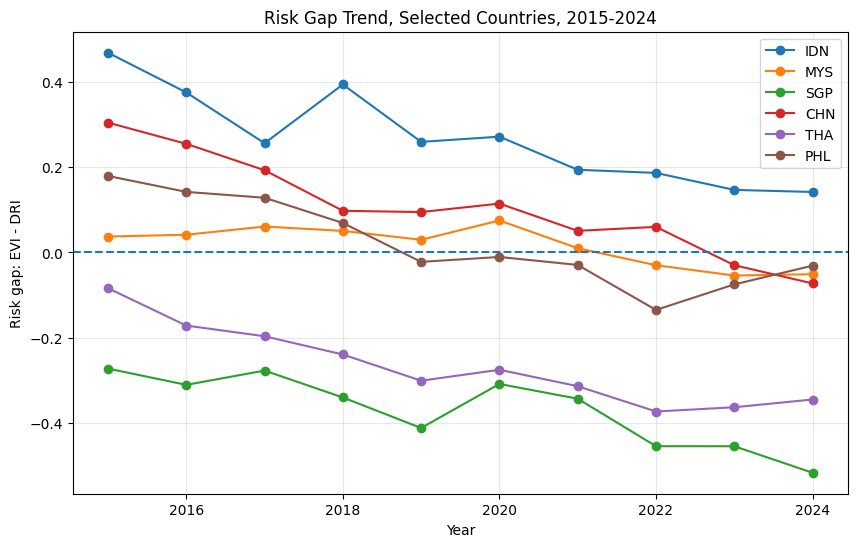

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_risk_gap_trend_selected_2015_2024.png


In [7]:
#5.risk gap trend line
trend_ctys=["IDN","MYS","SGP","CHN","THA","PHL"]
trend_df=index_df[index_df["country_code"].isin(trend_ctys)].copy()
plt.figure(figsize=(10,6))
for c in trend_ctys:
    temp=trend_df[trend_df["country_code"]==c].sort_values("year")
    plt.plot(temp["year"],temp["risk_gap"],marker="o",label=c)

plt.axhline(0,linestyle="--")
plt.xlabel("Year")
plt.ylabel("Risk gap: EVI - DRI")
plt.title("Risk Gap Trend, Selected Countries, 2015-2024")
plt.legend()
plt.grid(True,alpha=0.3)
fig_path=fig_dir/"fig_risk_gap_trend_selected_2015_2024.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()
print("figure saved:",fig_path)

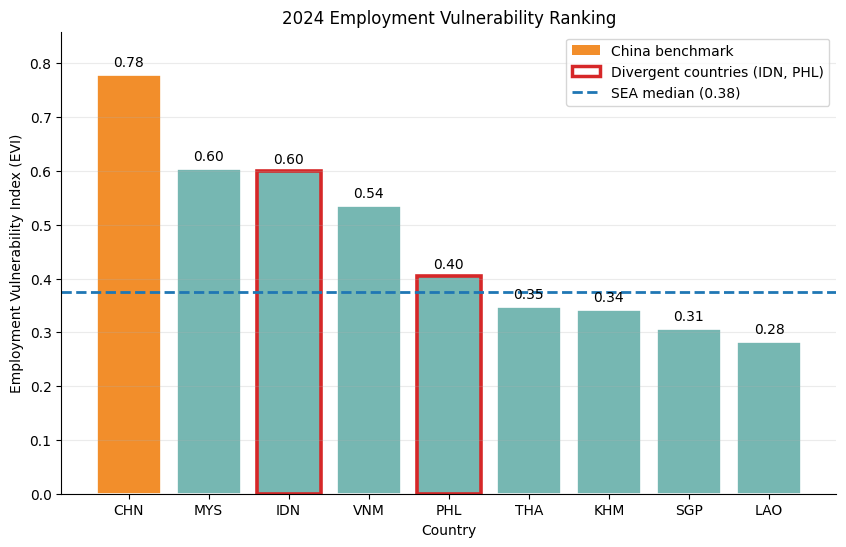

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_evi_ranking.png


In [8]:
#6.2024 EVI ranking improved
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
evi_rank=matrix_df.sort_values("evi_main",ascending=False).copy()
evi_median=evi_rank[evi_rank["is_benchmark"]==False]["evi_main"].median()
bar_colors=[]
edge_colors=[]
line_widths=[]

for i,r in evi_rank.iterrows():
    if r["country_code"]=="CHN":
        bar_colors.append("#F28E2B")
    else:
        bar_colors.append("#76B7B2")

    if r["country_code"] in ["IDN","PHL"]:
        edge_colors.append("#D62728")
        line_widths.append(2.6)
    else:
        edge_colors.append("white")
        line_widths.append(1.2)

plt.figure(figsize=(10,6))
bars=plt.bar(evi_rank["country_code"],evi_rank["evi_main"],color=bar_colors,
    edgecolor=edge_colors,linewidth=line_widths)
plt.axhline(evi_median,linestyle="--",linewidth=2,color="#1f77b4")
for bar in bars:
    h=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,h+0.01,f"{h:.2f}",
        ha="center",va="bottom",fontsize=10)

legend_handles=[Patch(facecolor="#F28E2B",edgecolor="none",label="China benchmark"),
    Patch(facecolor="white",edgecolor="#D62728",linewidth=2.5,
          label="Divergent countries (IDN, PHL)"),
    Line2D([0],[0],color="#1f77b4",linestyle="--",linewidth=2,
           label=f"SEA median ({evi_median:.2f})")]
plt.legend(handles=legend_handles,loc="upper right",frameon=True)
plt.xlabel("Country")
plt.ylabel("Employment Vulnerability Index (EVI)")
plt.title("2024 Employment Vulnerability Ranking")
plt.grid(axis="y",alpha=0.25)
plt.ylim(0,evi_rank["evi_main"].max()+0.08)
ax=plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig_path=fig_dir/"fig_2024_evi_ranking.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()

print("figure saved:",fig_path)

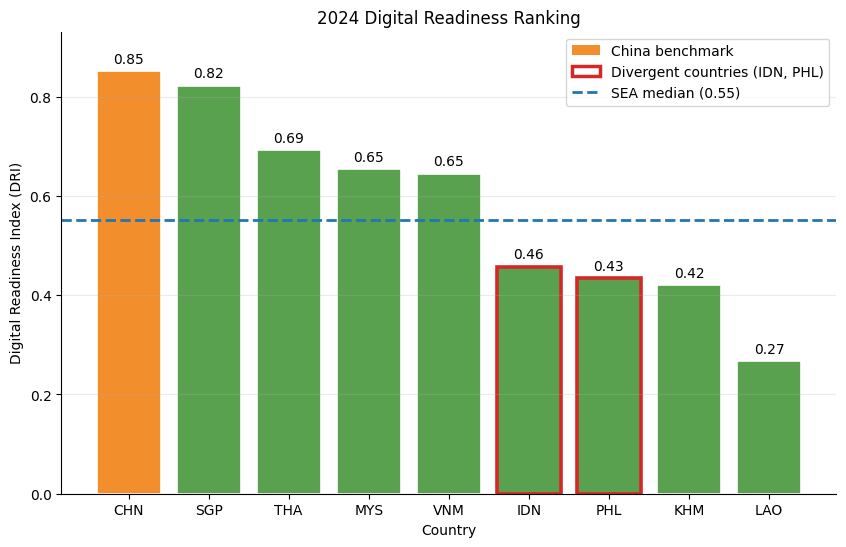

figure saved: /content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_dri_ranking.png


In [9]:
#7.2024 DRI ranking improved
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
dri_rank=matrix_df.sort_values("dri",ascending=False).copy()
dri_median=dri_rank[dri_rank["is_benchmark"]==False]["dri"].median()
bar_colors=[]
edge_colors=[]
line_widths=[]
for i,r in dri_rank.iterrows():
    if r["country_code"]=="CHN":
        bar_colors.append("#F28E2B")
    else:
        bar_colors.append("#59A14F")

    if r["country_code"] in ["IDN","PHL"]:
        edge_colors.append("#D62728")
        line_widths.append(2.6)
    else:
        edge_colors.append("white")
        line_widths.append(1.2)
plt.figure(figsize=(10,6))

bars=plt.bar(dri_rank["country_code"],dri_rank["dri"],color=bar_colors,
             edgecolor=edge_colors,linewidth=line_widths)
plt.axhline(dri_median,linestyle="--",linewidth=2,color="#1f77b4")
for bar in bars:
    h=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,h+0.01,f"{h:.2f}",
        ha="center",va="bottom",fontsize=10)

legend_handles=[Patch(facecolor="#F28E2B",edgecolor="none",label="China benchmark"),
    Patch(facecolor="white",edgecolor="#D62728",linewidth=2.5,
          label="Divergent countries (IDN, PHL)"),
    Line2D([0],[0],color="#1f77b4",linestyle="--",linewidth=2,
           label=f"SEA median ({dri_median:.2f})")]
plt.legend(handles=legend_handles,loc="upper right",frameon=True)
plt.xlabel("Country")
plt.ylabel("Digital Readiness Index (DRI)")
plt.title("2024 Digital Readiness Ranking")
plt.grid(axis="y",alpha=0.25)
plt.ylim(0,dri_rank["dri"].max()+0.08)
ax=plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig_path=fig_dir/"fig_2024_dri_ranking.png"
plt.savefig(fig_path,dpi=300,bbox_inches="tight")
plt.show()

print("figure saved:",fig_path)

In [10]:
#8.check saved figures
for f in fig_dir.glob("*.png"):
    print(f)

/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_readiness_matrix.png
/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_kmeans_scatter_2019_2024.png
/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_risk_gap_bar.png
/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_risk_gap_trend_selected_2015_2024.png
/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_evi_ranking.png
/content/drive/MyDrive/STQD6324_Labour_Shock/figures/fig_2024_dri_ranking.png
